In [4]:
print(f"Scala version: {sc._jvm.scala.util.Properties.versionString()}")

Scala version: version 2.13.16


In [1]:
import os
os.environ["PYSPARK_PYTHON"] = "python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python"

In [2]:
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [3]:
def generate_logistics_event():
    distance = round(random.uniform(10, 500), 2)
    speed = random.uniform(40, 90)
    weather = random.choice(['Clear', 'Rainy', 'Stormy'])
    traffic = random.choice(['Low', 'Moderate', 'Heavy'])

    delay = random.uniform(2, 8)

    if weather == 'Stormy':
        delay += random.uniform(15, 25)
    elif weather == 'Rainy':
        delay += random.uniform(5, 12)

    if traffic == 'Heavy':
        delay += random.uniform(10, 20)

    delay -= (speed / 20)
    delay = max(0, round(delay, 2))

    return {
        "distance_km": distance,
        "speed_kmh": speed,
        "weather": weather,
        "traffic": traffic,
        "delay_minutes": delay
    }

# Create dataset
data = [generate_logistics_event() for _ in range(5000)]
df = pd.DataFrame(data)

df.head()

,distance_km,speed_kmh,weather,traffic,delay_minutes
0,162.46,69.250080,Rainy,Low,10.90
1,49.42,75.329624,Stormy,Moderate,19.32
2,385.86,80.745577,Stormy,Heavy,40.29
3,99.87,43.460065,Clear,Low,4.21
4,191.35,50.498331,Rainy,Moderate,12.01


In [3]:
from data_generator import generate_logistics_event

In [4]:
# Create dataset
data = [generate_logistics_event() for _ in range(5000)]
df = pd.DataFrame(data)

df.head()

,distance_km,speed_kmh,weather,traffic,delay_minutes
0,480.20,54.370977,Clear,Heavy,16.29
1,393.93,58.981942,Stormy,Heavy,34.76
2,380.88,62.951252,Rainy,Heavy,25.78
3,488.58,45.143286,Rainy,Heavy,29.93
4,381.33,61.242787,Stormy,Moderate,26.76


In [5]:
X = df.drop("delay_minutes", axis=1)
y = df["delay_minutes"]

# One-hot encoding
X_encoded = pd.get_dummies(X)

X_encoded.head()

,distance_km,speed_kmh,weather_Clear,weather_Rainy,weather_Stormy,traffic_Heavy,traffic_Low,traffic_Moderate
0,480.20,54.370977,True,False,False,True,False,False
1,393.93,58.981942,False,False,True,True,False,False
2,380.88,62.951252,False,True,False,True,False,False
3,488.58,45.143286,False,True,False,True,False,False
4,381.33,61.242787,False,False,True,False,False,True


In [6]:
#train_test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [7]:
# train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [8]:
# validate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2.8372058
R2 Score: 0.8951975267980592


#### Evaluation Scores:

mean absolute error: <5 is good

r^2 score: between 0 to 1, close to 1 good

In [9]:
# compare the predicted values with actual
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,3.06,2.1437
1,43.81,37.0898
2,4.25,4.0894
3,9.74,10.5188
4,17.84,19.6578
5,21.50,20.2510
6,1.99,2.9645
7,33.17,37.2105
8,23.00,21.5916
9,2.81,3.3754


In [10]:
# feature importance visually
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X_encoded.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feat_df.head(10)

,Feature,Importance
4,weather_Stormy,0.452224
5,traffic_Heavy,0.308037
0,distance_km,0.073978
3,weather_Rainy,0.060116
2,weather_Clear,0.034455
1,speed_kmh,0.025628
6,traffic_Low,0.024138
7,traffic_Moderate,0.021425


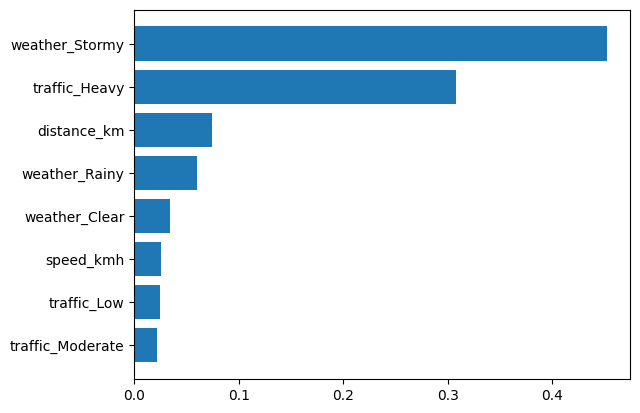

In [11]:
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.show()

In [14]:
# save the model
joblib.dump(model, "rf_model.pkl")
joblib.dump(X_encoded.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

### TEST WITH CUSTOM INPUT

In [12]:
sample = {
    "distance_km": 120,
    "speed_kmh": 50,
    "weather": "Stormy",
    "traffic": "Heavy"
}

sample_df = pd.DataFrame([sample])
sample_df = pd.get_dummies(sample_df)

# Align columns
for col in X_encoded.columns:
    if col not in sample_df:
        sample_df[col] = 0

sample_df = sample_df[X_encoded.columns]

print("Predicted delay:", model.predict(sample_df)[0])

Predicted delay: 49.95766187249537
